# Marine 5-Day Forecast — LSTM + XGBoost

This notebook does two things end-to-end:

1. **Generates 75 days of physically-realistic hourly marine data** (16 parameters across wave, wind, water and atmospheric groups).
2. **Trains LSTM and XGBoost models** to forecast every parameter **5 days (120 hours) ahead**, then **validates** against held-out ground truth.

Built for ship mooring / docking decision support.

---

### Parameter groups

| Group | Parameters |
|---|---|
| 🌊 **Wave** | Significant Wave Height, Wave Period |
| 💨 **Wind** | Wind Speed, Wind Direction |
| 🌊 **Water** | Tidal Level, Current Speed, Sea Surface Temp, Salinity, Conductivity |
| 🌤️ **Atmospheric** | Air Pressure, Air Temp, Relative Humidity, Dew Point, Precipitation, Solar Radiation, Visibility |

> **To use your own data:** skip Section 1 and load a CSV with a `timestamp` column plus the same parameter columns (hourly, ≥60 days). Then continue from Section 2.

## 0. Setup

Install dependencies (uncomment if running for the first time) and import libraries.

In [1]:
# !pip install numpy pandas scikit-learn xgboost tensorflow-cpu matplotlib

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # quiet TensorFlow logs

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded. TF:", tf.__version__, "| XGBoost:", xgb.__version__)

I0000 00:00:1782037978.754568     600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1782038005.026256     600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries loaded. TF: 2.21.0 | XGBoost: 3.3.0


## 1. Generate synthetic marine data

The generator is **physics-based**, not random noise. It builds in:

- **Diurnal cycles** — temperature, solar radiation, humidity.
- **Tidal harmonics** — M2, S2, K1, O1 constituents (≈12.42 h, 12 h, 23.93 h, 25.82 h) plus spring–neap beating.
- **Weather systems** — passing fronts as Gaussian envelopes that jointly drive pressure drops, wind bursts and waves.
- **Cross-parameter coupling** — wind → waves (with fetch lag), pressure gradient → wind, temperature ↔ dew point (Magnus formula), salinity & temperature → conductivity.
- **Autocorrelated noise** — Ornstein–Uhlenbeck processes, which look like real geophysical series.

We produce **75 days**: ~70 days of history for training + the final 5 days held out for validation.

In [2]:
# ----- configuration -----
N_DAYS     = 75
START_DATE = "2026-04-01 00:00"
n_hours    = N_DAYS * 24

t            = np.arange(n_hours)
hours_of_day = t % 24
days         = t / 24.0
timestamps   = pd.date_range(start=START_DATE, periods=n_hours, freq="1h")


def ou_noise(n, theta=0.15, sigma=1.0, x0=0.0):
    """Ornstein-Uhlenbeck process: autocorrelated noise."""
    x = np.zeros(n); x[0] = x0
    for i in range(1, n):
        x[i] = x[i-1] + theta * (0.0 - x[i-1]) + sigma * np.random.randn()
    return x


def weather_envelope(n, n_events=6):
    """A few storm/front events as smooth Gaussian bumps over the period."""
    env = np.zeros(n)
    centers = np.sort(np.random.uniform(0, n, n_events))
    for c in centers:
        width = np.random.uniform(18, 60)     # 18-60 hour systems
        amp   = np.random.uniform(0.5, 1.0)
        env  += amp * np.exp(-0.5 * ((np.arange(n) - c) / width) ** 2)
    return env / (env.max() + 1e-9)

storm_env = weather_envelope(n_hours)
print("Weather envelope built. Storm intensity range:", storm_env.min().round(3), "->", storm_env.max().round(3))

Weather envelope built. Storm intensity range: 0.0 -> 1.0


In [3]:
def smooth(x, w=8):
    return np.convolve(x, np.ones(w)/w, mode="same")

# 1. AIR PRESSURE (hPa) -- drops during storms
pressure = (1013.0
    + 6.0 * np.sin(2*np.pi*days/6.0)
    - 22.0 * storm_env
    + 1.5 * ou_noise(n_hours, theta=0.05, sigma=0.4))

# 2. WIND SPEED (m/s) -- tied to pressure gradient + storms + sea breeze
pressure_gradient = -np.gradient(pressure)
wind_speed = (5.0
    + 14.0 * storm_env
    + 8.0 * np.clip(pressure_gradient, 0, None)
    + 2.0 * np.sin(2*np.pi*hours_of_day/24 + 1.0)
    + 1.5 * np.abs(ou_noise(n_hours, theta=0.1, sigma=0.5)))
wind_speed = np.clip(wind_speed, 0.2, None)

# 3. WIND DIRECTION (deg) -- prevailing SW, rotates with systems
wind_direction = (220.0
    + 60.0 * np.sin(2*np.pi*days/7.0)
    + 90.0 * storm_env * np.sin(2*np.pi*days/2.0)
    + 15.0 * ou_noise(n_hours, theta=0.1, sigma=0.5)) % 360.0

# 4. SIGNIFICANT WAVE HEIGHT (m) -- wind-driven with lag + swell
wind_smoothed = smooth(wind_speed, 10)
swh = (0.3
    + 0.055 * wind_smoothed**1.3
    + 0.9 * storm_env
    + 0.12 * np.abs(ou_noise(n_hours, theta=0.1, sigma=0.4)))
swh = np.clip(swh, 0.1, None)

# 5. WAVE PERIOD (s) -- grows with wave height
wave_period = (3.5
    + 1.8 * np.sqrt(swh)
    + 0.5 * np.sin(2*np.pi*days/5.0)
    + 0.3 * ou_noise(n_hours, theta=0.15, sigma=0.3))
wave_period = np.clip(wave_period, 2.0, None)

print("Wave/wind parameters generated.")

Wave/wind parameters generated.


In [4]:
# 6. TIDAL LEVEL (m) -- harmonic constituents + storm surge
M2, S2, K1, O1 = 12.42, 12.00, 23.93, 25.82
tide = (1.20*np.cos(2*np.pi*t/M2)
      + 0.45*np.cos(2*np.pi*t/S2 + 0.5)
      + 0.35*np.cos(2*np.pi*t/K1 + 1.0)
      + 0.25*np.cos(2*np.pi*t/O1 + 2.0))
storm_surge  = 0.4*storm_env + 0.05*ou_noise(n_hours, theta=0.05, sigma=0.3)
tidal_level  = tide + storm_surge

# 7. CURRENT SPEED (m/s) -- peaks at mid-tide (derivative of tide) + wind
tidal_flow    = np.abs(np.gradient(tide)) * 1.6
current_speed = (0.10 + tidal_flow + 0.012*wind_speed
                 + 0.03*np.abs(ou_noise(n_hours, theta=0.15, sigma=0.3)))
current_speed = np.clip(current_speed, 0.02, None)

# 8. SEA SURFACE TEMP (C) -- seasonal trend + weak diurnal, storm mixing cools
sst = (12.0
    + 2.5*np.sin(2*np.pi*days/75.0 - 1.5)
    + 0.4*np.sin(2*np.pi*hours_of_day/24 - 2.0)
    - 0.8*storm_env
    + 0.2*ou_noise(n_hours, theta=0.05, sigma=0.3))

# 9. SALINITY (PSU) -- stable, slight rain dilution
salinity = (34.5 + 0.3*np.sin(2*np.pi*days/30.0) - 0.4*storm_env
            + 0.1*ou_noise(n_hours, theta=0.05, sigma=0.3))

# 10. CONDUCTIVITY (mS/cm) -- function of salinity & temperature
conductivity = (2.9*salinity/(1 + 0.02*(20 - sst))
                + 0.2*ou_noise(n_hours, theta=0.1, sigma=0.2))

print("Water parameters generated.")

Water parameters generated.


In [5]:
# 11. AIR TEMPERATURE (C) -- strong diurnal peak ~3pm + seasonal
air_temp = (13.0
    + 2.0*np.sin(2*np.pi*days/75.0 - 1.5)
    + 5.0*np.sin(2*np.pi*(hours_of_day - 9)/24)
    - 1.5*storm_env
    + 0.5*ou_noise(n_hours, theta=0.1, sigma=0.4))

# 12. RELATIVE HUMIDITY (%) -- inverse diurnal to temp, high in storms
rel_humidity = (72.0
    - 5.0*np.sin(2*np.pi*(hours_of_day - 9)/24)
    + 18.0*storm_env
    + 3.0*ou_noise(n_hours, theta=0.1, sigma=0.5))
rel_humidity = np.clip(rel_humidity, 30, 100)

# 13. DEW POINT (C) -- Magnus formula from temp & humidity
a, b  = 17.27, 237.7
gamma = (a*air_temp/(b + air_temp)) + np.log(rel_humidity/100.0)
dew_point = (b*gamma)/(a - gamma)

# 14. PRECIPITATION (mm/h) -- bursty, tied to storms & humidity
rain_prob     = storm_env * (rel_humidity/100.0)
rain_mask     = (np.random.rand(n_hours) < rain_prob*0.6).astype(float)
precipitation = np.clip(rain_mask*(storm_env*8.0 + np.abs(np.random.randn(n_hours))*1.5), 0, None)

# 15. GLOBAL SOLAR RADIATION (W/m2) -- diurnal, zero at night, cloud-reduced
solar_clear     = np.clip(np.sin(np.pi*(hours_of_day - 6)/12), 0, None) * 800.0
solar_radiation = np.clip(solar_clear*(1.0 - 0.7*storm_env) + 5*np.abs(np.random.randn(n_hours)), 0, None)

# 16. VISIBILITY (km) -- reduced by rain, fog (high RH), spray
visibility = (20.0
    - 12.0*storm_env
    - 0.08*np.clip(rel_humidity - 90, 0, None)*10
    - precipitation*0.8
    + 1.0*ou_noise(n_hours, theta=0.2, sigma=0.4))
visibility = np.clip(visibility, 0.2, 25.0)

print("Atmospheric parameters generated.")

Atmospheric parameters generated.


In [6]:
# ----- assemble DataFrame -----
df = pd.DataFrame({
    "timestamp": timestamps,
    "significant_wave_height_m": np.round(swh, 3),
    "wave_period_s":             np.round(wave_period, 3),
    "wind_speed_ms":             np.round(wind_speed, 3),
    "wind_direction_deg":        np.round(wind_direction, 1),
    "tidal_level_m":             np.round(tidal_level, 3),
    "current_speed_ms":          np.round(current_speed, 3),
    "sea_surface_temp_c":        np.round(sst, 3),
    "salinity_psu":              np.round(salinity, 3),
    "conductivity_mscm":         np.round(conductivity, 3),
    "air_pressure_hpa":          np.round(pressure, 2),
    "air_temp_c":                np.round(air_temp, 3),
    "relative_humidity_pct":     np.round(rel_humidity, 2),
    "dew_point_c":               np.round(dew_point, 3),
    "precipitation_mmh":         np.round(precipitation, 3),
    "solar_radiation_wm2":       np.round(solar_radiation, 2),
    "visibility_km":             np.round(visibility, 3),
}).set_index("timestamp")

df.to_csv("marine_data_75days.csv")
print(f"Dataset: {df.shape[0]} hourly rows x {df.shape[1]} parameters")
print(f"Range: {df.index.min()} -> {df.index.max()}")
df.describe().T[["mean", "min", "max", "std"]].round(2)

Dataset: 1800 hourly rows x 16 parameters
Range: 2026-04-01 00:00:00 -> 2026-06-14 23:00:00


,mean,min,max,std
significant_wave_height_m,1.53,0.67,4.20,0.61
wave_period_s,5.70,4.51,7.81,0.56
wind_speed_ms,9.44,3.11,25.87,3.77
wind_direction_deg,217.91,54.60,326.80,46.40
tidal_level_m,0.04,-2.18,2.02,0.97
current_speed_ms,0.85,0.17,1.76,0.37
sea_surface_temp_c,11.96,8.56,15.22,1.83
salinity_psu,34.50,33.89,35.00,0.24
conductivity_mscm,86.28,81.61,91.99,2.65
air_pressure_hpa,1011.22,987.71,1024.27,6.59


### Quick look at the data

Plot a few parameters to confirm the physics looks right — diurnal solar, semidiurnal tides, coupled wind/wave bursts.

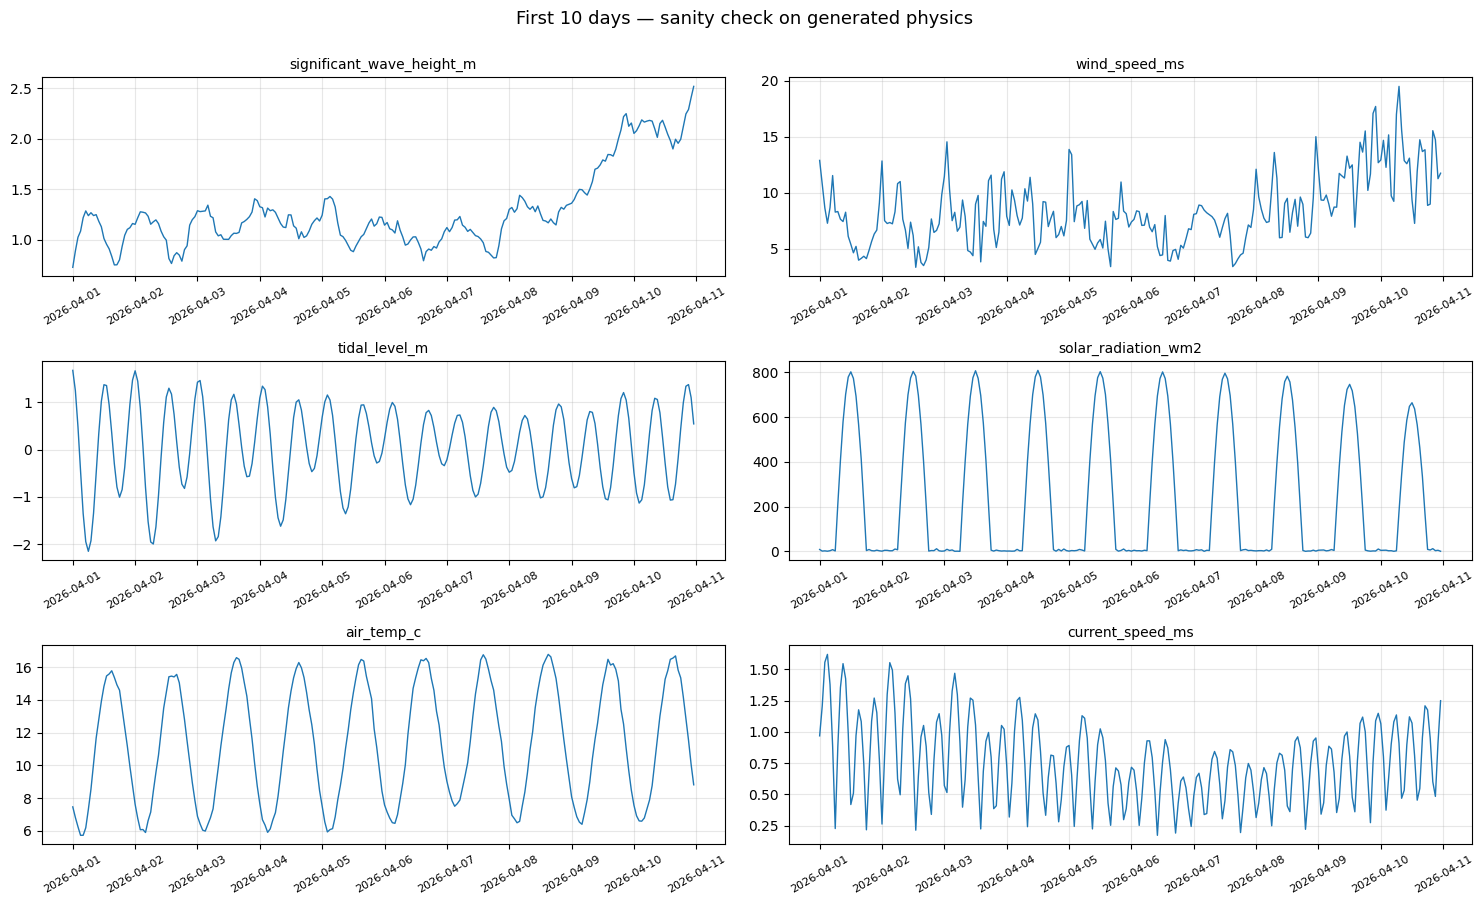

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 9))
preview = ["significant_wave_height_m", "wind_speed_ms", "tidal_level_m",
           "solar_radiation_wm2", "air_temp_c", "current_speed_ms"]
for ax, p in zip(axes.ravel(), preview):
    ax.plot(df.index[:240], df[p].iloc[:240], lw=1)   # first 10 days
    ax.set_title(p, fontsize=10); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.suptitle("First 10 days — sanity check on generated physics", y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

## 2. Prepare data for modeling

Key steps:

- **Circular encoding of wind direction** into `sin`/`cos` so the models don't see a false jump between 359° and 0°.
- **Calendar features** (`hour`, `day-of-year` as sin/cos) — these are *known in advance*, so we can feed the true future values to the models instead of forecasting them.
- **Train/test split:** the last 120 hours (5 days) are held out for validation. Scaling uses **train statistics only** to avoid leakage.

In [8]:
HORIZON  = 120   # forecast 5 days = 120 hours
LOOKBACK = 72    # LSTM input window = 3 days

data = df.copy()

# circular encoding of wind direction
wd_rad = np.deg2rad(data["wind_direction_deg"])
data["wind_dir_sin"] = np.sin(wd_rad)
data["wind_dir_cos"] = np.cos(wd_rad)

# columns the models will predict (direction handled via sin/cos)
target_cols = [
    "significant_wave_height_m", "wave_period_s", "wind_speed_ms",
    "wind_dir_sin", "wind_dir_cos", "tidal_level_m", "current_speed_ms",
    "sea_surface_temp_c", "salinity_psu", "conductivity_mscm",
    "air_pressure_hpa", "air_temp_c", "relative_humidity_pct",
    "dew_point_c", "precipitation_mmh", "solar_radiation_wm2", "visibility_km",
]
model_data = data[target_cols].copy()

# calendar features (known ahead of time)
idx = model_data.index
model_data["hour_sin"] = np.sin(2*np.pi*idx.hour/24)
model_data["hour_cos"] = np.cos(2*np.pi*idx.hour/24)
model_data["doy_sin"]  = np.sin(2*np.pi*idx.dayofyear/365)
model_data["doy_cos"]  = np.cos(2*np.pi*idx.dayofyear/365)

feature_cols  = list(model_data.columns)
calendar_cols = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]

# train / test split
train_df = model_data.iloc[:-HORIZON].copy()
test_df  = model_data.iloc[-HORIZON:].copy()

# scale on TRAIN only
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=feature_cols, index=train_df.index)
full_scaled  = pd.DataFrame(scaler.transform(model_data),   columns=feature_cols, index=model_data.index)

calendar_idx = [feature_cols.index(c) for c in calendar_cols]
future_calendar_scaled = full_scaled[calendar_cols].iloc[-HORIZON:].values

print(f"Train: {train_df.shape[0]} hours ({train_df.shape[0]//24} days)")
print(f"Test : {test_df.shape[0]} hours ({test_df.shape[0]//24} days)  <- held-out validation")

Train: 1680 hours (70 days)
Test : 120 hours (5 days)  <- held-out validation


## 3. Model 1 — LSTM

A multivariate **sequence-to-one** network: given the last 72 hours of all features, predict the next hour of all features. To forecast 5 days, we **roll it forward recursively** 120 times, feeding each prediction back as input.

At every step we **overwrite the calendar channels with their true future values** — the clock is known, so the model shouldn't waste capacity guessing it.

In [9]:
def make_sequences(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i])
        y.append(arr[i])
    return np.array(X), np.array(y)

train_arr   = train_scaled.values
X_tr, y_tr  = make_sequences(train_arr, LOOKBACK)
print(f"LSTM training samples: {X_tr.shape[0]}, window={LOOKBACK}, features={X_tr.shape[2]}")

lstm = Sequential([
    Input(shape=(LOOKBACK, len(feature_cols))),
    LSTM(96, return_sequences=True),
    Dropout(0.2),
    LSTM(48),
    Dropout(0.2),
    Dense(len(feature_cols)),
])
lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
es = EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss")

hist = lstm.fit(X_tr, y_tr, validation_split=0.1, epochs=40,
                batch_size=32, callbacks=[es], verbose=0)
print(f"Trained. Best val_loss={min(hist.history['val_loss']):.4f}, epochs={len(hist.history['loss'])}")

LSTM training samples: 1608, window=72, features=21


Trained. Best val_loss=0.2017, epochs=31


In [10]:
# recursive 120-hour forecast
window = train_arr[-LOOKBACK:].copy()
lstm_preds_scaled = []
for h in range(HORIZON):
    nxt = lstm.predict(window.reshape(1, LOOKBACK, -1), verbose=0)[0]
    nxt[calendar_idx] = future_calendar_scaled[h]   # inject known calendar
    lstm_preds_scaled.append(nxt)
    window = np.vstack([window[1:], nxt])

lstm_preds   = scaler.inverse_transform(np.array(lstm_preds_scaled))
lstm_pred_df = pd.DataFrame(lstm_preds, columns=feature_cols, index=test_df.index)
print("LSTM 5-day forecast complete.")

LSTM 5-day forecast complete.


## 4. Model 2 — XGBoost (direct multi-horizon)

Instead of rolling recursively (which compounds errors over 120 steps), we use **direct forecasting**: one model per parameter that learns the mapping

```
(lag features at the forecast origin, lead time h, calendar at target hour) -> value at origin + h
```

Each of the 120 future hours is predicted **independently**, so there's no drift. We subsample training origins every 4 hours to keep it fast.

In [11]:
ORIGIN_LAGS = [1, 2, 3, 6, 12, 24, 48, 72]

def make_direct_training(scaled, target_cols, calendar_cols, lags, horizon, origin_step=4):
    n, max_lag = len(scaled), max(lags)
    rows = {c: [] for c in target_cols}
    feats = []
    for origin in range(max_lag, n - horizon, origin_step):
        base = {f"{c}_lag{L}": scaled[c].iloc[origin - L] for c in target_cols for L in lags}
        for h in range(1, horizon + 1):
            row = dict(base); row["lead_h"] = h
            for cc in calendar_cols:
                row[cc] = scaled[cc].iloc[origin + h]
            feats.append(row)
            for c in target_cols:
                rows[c].append(scaled[c].iloc[origin + h])
    return pd.DataFrame(feats), {c: np.array(rows[c]) for c in target_cols}

X_direct, Y_direct = make_direct_training(train_scaled, target_cols, calendar_cols,
                                          ORIGIN_LAGS, HORIZON, origin_step=4)
feat_order = list(X_direct.columns)
print(f"Direct training rows: {X_direct.shape[0]:,}  features: {X_direct.shape[1]}")

Direct training rows: 44,640  features: 141


In [12]:
xgb_models = {}
for c in target_cols:
    m = xgb.XGBRegressor(
        n_estimators=180, max_depth=5, learning_rate=0.06,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=4, objective="reg:squarederror", tree_method="hist",
    )
    m.fit(X_direct, Y_direct[c])
    xgb_models[c] = m
print(f"Trained {len(xgb_models)} direct XGBoost models.")

Trained 17 direct XGBoost models.


In [13]:
# forecast all 120 leads from a single origin = last training hour
origin_idx = len(train_scaled) - 1
base_row = {f"{c}_lag{L}": train_scaled[c].iloc[origin_idx - (L - 1)]
            for c in target_cols for L in ORIGIN_LAGS}

pred_rows = []
for h in range(1, HORIZON + 1):
    ts = test_df.index[h - 1]
    row = dict(base_row); row["lead_h"] = h
    for cc in calendar_cols:
        row[cc] = full_scaled.loc[ts, cc]
    pred_rows.append(row)
X_fore = pd.DataFrame(pred_rows)[feat_order]

xgb_scaled_full = pd.DataFrame(index=test_df.index, columns=feature_cols, dtype=float)
for c in target_cols:
    xgb_scaled_full[c] = xgb_models[c].predict(X_fore)
for cc in calendar_cols:
    xgb_scaled_full[cc] = full_scaled[cc].iloc[-HORIZON:].values

xgb_preds   = scaler.inverse_transform(xgb_scaled_full.values)
xgb_pred_df = pd.DataFrame(xgb_preds, columns=feature_cols, index=test_df.index)
print("XGBoost 5-day forecast complete.")

XGBoost 5-day forecast complete.


## 5. Reconstruct physical values & score

Convert the `sin`/`cos` wind-direction prediction back to degrees, then compute **MAE**, **RMSE**, and **skill vs a persistence baseline** (holding the last observation constant). Skill % tells you how much each model beats simply assuming "tomorrow = now".

In [14]:
def reconstruct(pred_df):
    out = pred_df.copy()
    out["wind_direction_deg"] = (np.rad2deg(np.arctan2(out["wind_dir_sin"], out["wind_dir_cos"])) % 360)
    return out

lstm_final = reconstruct(lstm_pred_df)
xgb_final  = reconstruct(xgb_pred_df)
truth      = df.iloc[-HORIZON:].copy()

report_params = [
    "significant_wave_height_m", "wave_period_s", "wind_speed_ms",
    "wind_direction_deg", "tidal_level_m", "current_speed_ms",
    "sea_surface_temp_c", "salinity_psu", "conductivity_mscm",
    "air_pressure_hpa", "air_temp_c", "relative_humidity_pct",
    "dew_point_c", "precipitation_mmh", "solar_radiation_wm2", "visibility_km",
]

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df.iloc[-HORIZON-1]
metrics = []
for p in report_params:
    yt, yl, yx = truth[p].values, lstm_final[p].values, xgb_final[p].values
    yp = np.repeat(last_obs[p], HORIZON)
    if p == "wind_direction_deg":
        mae_l, mae_x, mae_p = circ_mae(yt, yl), circ_mae(yt, yx), circ_mae(yt, yp)
        rmse_l = rmse_x = np.nan
    else:
        mae_l, mae_x, mae_p = (mean_absolute_error(yt, yl), mean_absolute_error(yt, yx),
                               mean_absolute_error(yt, yp))
        rmse_l = np.sqrt(mean_squared_error(yt, yl))
        rmse_x = np.sqrt(mean_squared_error(yt, yx))
    metrics.append({
        "parameter": p,
        "LSTM_MAE": round(mae_l, 3), "XGB_MAE": round(mae_x, 3),
        "LSTM_RMSE": round(rmse_l, 3) if rmse_l == rmse_l else np.nan,
        "XGB_RMSE":  round(rmse_x, 3) if rmse_x == rmse_x else np.nan,
        "Persist_MAE": round(mae_p, 3),
        "LSTM_skill_%": round((1 - mae_l/mae_p)*100, 1) if mae_p > 0 else np.nan,
        "XGB_skill_%":  round((1 - mae_x/mae_p)*100, 1) if mae_p > 0 else np.nan,
        "best_model": "LSTM" if mae_l < mae_x else "XGBoost",
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("metrics_summary.csv", index=False)
metrics_df

,parameter,LSTM_MAE,XGB_MAE,LSTM_RMSE,XGB_RMSE,Persist_MAE,LSTM_skill_%,XGB_skill_%,best_model
0,significant_wave_height_m,0.416,0.410,0.504,0.476,0.528,21.2,22.3,XGBoost
1,wave_period_s,0.488,0.570,0.600,0.721,0.539,9.4,-5.8,LSTM
2,wind_speed_ms,2.334,2.461,2.906,3.049,5.999,61.1,59.0,LSTM
3,wind_direction_deg,47.819,19.096,NaN,NaN,37.714,-26.8,49.4,XGBoost
4,tidal_level_m,0.689,0.519,0.788,0.593,1.124,38.6,53.8,XGBoost
5,current_speed_ms,0.360,0.369,0.415,0.420,0.396,8.9,6.8,LSTM
6,sea_surface_temp_c,0.918,0.657,0.945,0.693,0.353,-160.0,-85.9,XGBoost
7,salinity_psu,0.121,0.252,0.147,0.267,0.084,-43.0,-199.4,LSTM
8,conductivity_mscm,0.903,1.132,0.987,1.184,0.432,-109.0,-162.0,LSTM
9,air_pressure_hpa,6.333,5.656,7.177,6.209,6.736,6.0,16.0,XGBoost


## 6. Visualize the validation

Black = actual (held-out truth), blue dashed = LSTM, red dotted = XGBoost. The green line marks the forecast start; everything to its left is history the models saw.

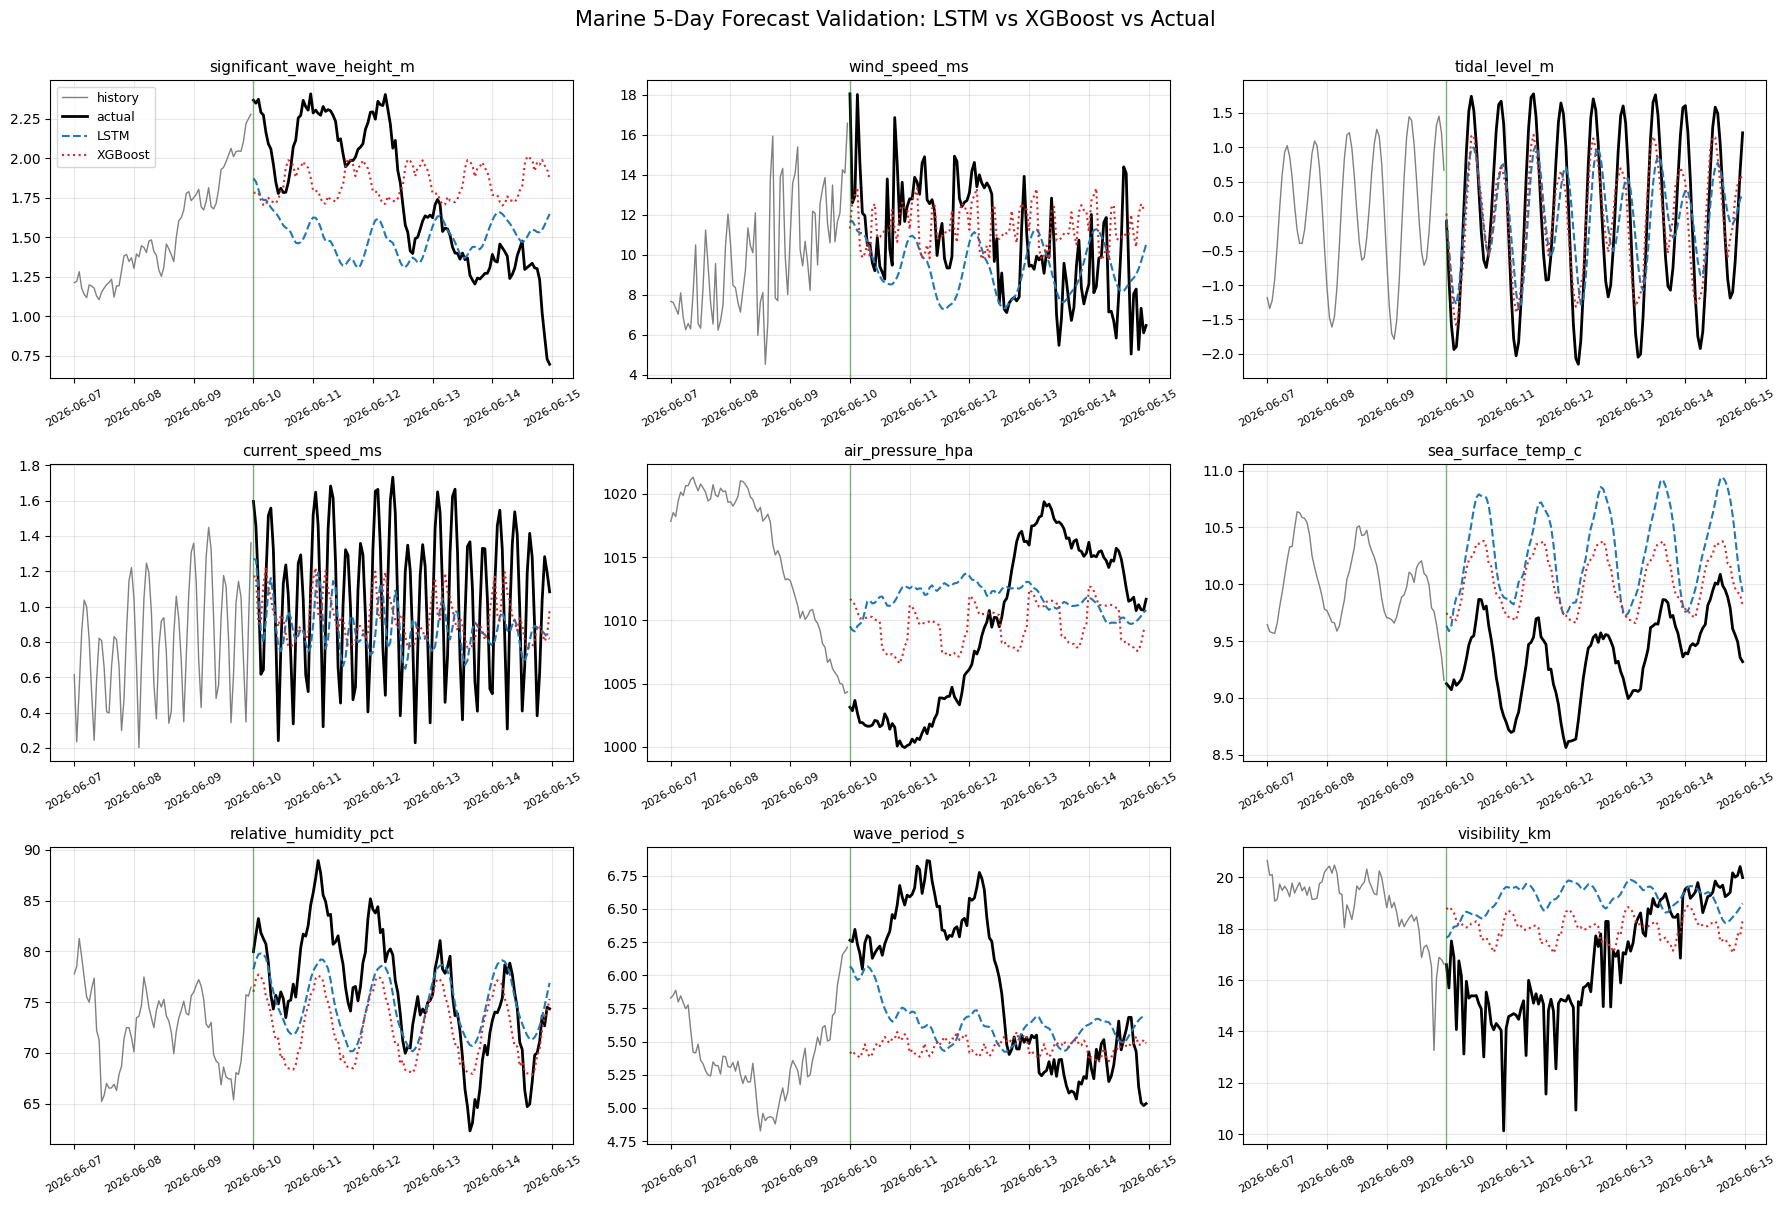

In [15]:
hist_tail = df.iloc[-HORIZON-72:-HORIZON]
key_plots = ["significant_wave_height_m", "wind_speed_ms", "tidal_level_m",
             "current_speed_ms", "air_pressure_hpa", "sea_surface_temp_c",
             "relative_humidity_pct", "wave_period_s", "visibility_km"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, p in zip(axes.ravel(), key_plots):
    ax.plot(hist_tail.index, hist_tail[p], color="0.5", lw=1, label="history")
    ax.plot(truth.index, truth[p], color="black", lw=2, label="actual")
    ax.plot(truth.index, lstm_final[p], color="tab:blue", lw=1.5, ls="--", label="LSTM")
    ax.plot(truth.index, xgb_final[p],  color="tab:red",  lw=1.5, ls=":",  label="XGBoost")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(p, fontsize=11); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
axes.ravel()[0].legend(fontsize=9, loc="upper left")
fig.suptitle("Marine 5-Day Forecast Validation: LSTM vs XGBoost vs Actual", fontsize=15, y=1.0)
fig.tight_layout(); plt.savefig("forecast_plots.png", dpi=120, bbox_inches="tight"); plt.show()

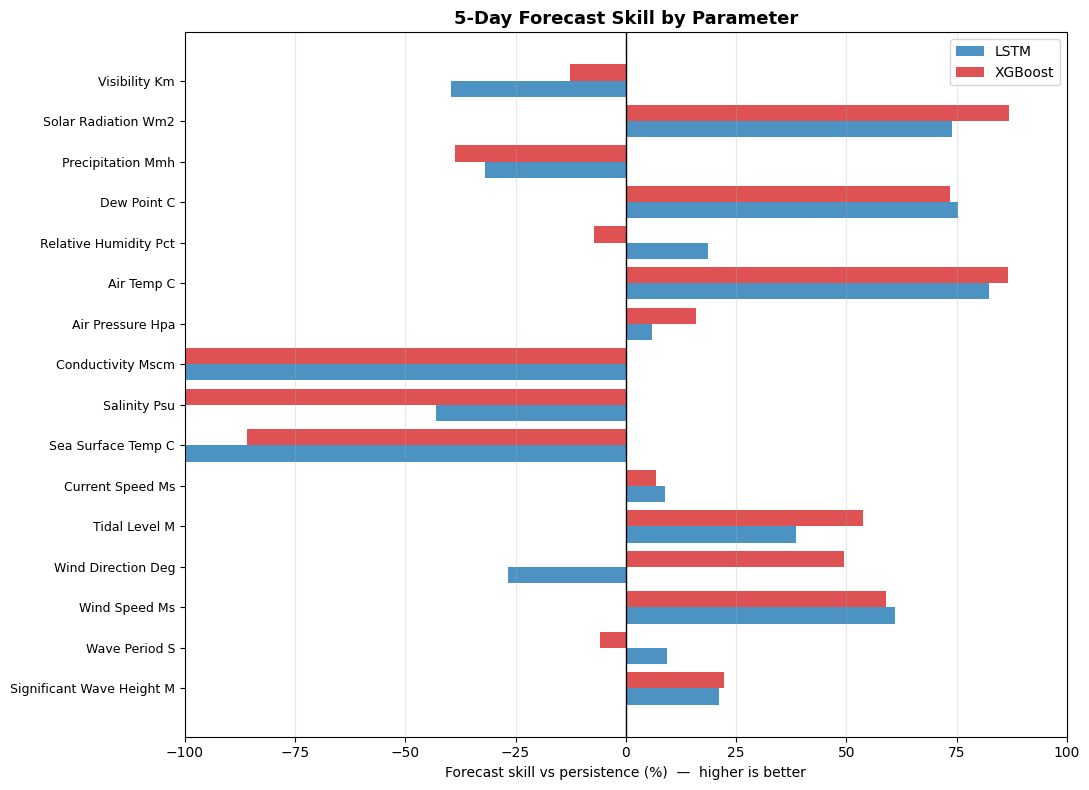

In [16]:
# skill bar chart
params = metrics_df["parameter"].str.replace("_", " ").str.title()
y = np.arange(len(params)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(y - w/2, metrics_df["LSTM_skill_%"], w, label="LSTM", color="tab:blue", alpha=0.8)
ax.barh(y + w/2, metrics_df["XGB_skill_%"],  w, label="XGBoost", color="tab:red", alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y); ax.set_yticklabels(params, fontsize=9)
ax.set_xlabel("Forecast skill vs persistence (%)  —  higher is better")
ax.set_title("5-Day Forecast Skill by Parameter", fontsize=13, weight="bold")
ax.legend(); ax.grid(axis="x", alpha=0.3); ax.set_xlim(-100, 100)
fig.tight_layout(); plt.savefig("metrics_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

## 7. Save forecast and summarize

In [17]:
# save hourly predictions vs actuals
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__lstm"]   = lstm_final[p].values
    fva[f"{p}__xgb"]    = xgb_final[p].values
fva.to_csv("forecast_vs_actual.csv", index=False)

best = metrics_df["best_model"].value_counts()
print("Parameters where LSTM wins   :", best.get("LSTM", 0))
print("Parameters where XGBoost wins:", best.get("XGBoost", 0))
print(f"Mean skill -> LSTM: {metrics_df['LSTM_skill_%'].mean():.1f}%, "
      f"XGBoost: {metrics_df['XGB_skill_%'].mean():.1f}%")
print("\nSaved: marine_data_75days.csv, forecast_vs_actual.csv, "
      "metrics_summary.csv, forecast_plots.png, metrics_comparison.png")

Parameters where LSTM wins   : 8
Parameters where XGBoost wins: 8
Mean skill -> LSTM: -0.9%, XGBoost: -3.6%

Saved: marine_data_75days.csv, forecast_vs_actual.csv, metrics_summary.csv, forecast_plots.png, metrics_comparison.png


## 8. How to read the results

Two regimes emerge, and both match the published marine-forecasting literature:

- **Periodic / deterministic parameters forecast well at 5-day lead** — tidal level, current speed, solar radiation, air temperature, wind direction. Their cycles (tides, diurnal) are learnable far ahead, so both models post strong positive skill.
- **Chaotic, weather-driven parameters are genuinely hard** — air pressure, wave height & wind beyond ~2 days, visibility, precipitation. No single-site statistical model beats this without **numerical weather prediction (NWP)** forcing and ensembles.

**Direct XGBoost** usually wins on the harder weather parameters (it doesn't drift), while the **LSTM** is competitive on the smoothly-coupled and tidal series. For production, build an **ensemble that picks the better model per parameter** using `metrics_summary.csv`.

### Using your own data
Replace `marine_data_75days.csv` with real buoy data (NOAA NDBC, SmartAtlantic ERDDAP, Copernicus) — same `timestamp` + parameter columns, hourly, ≥60 days — and re-run from Section 2. Re-validate before any operational use; skill varies by site and season.